In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

def load_movie_data():
    movie_data = pd.read_csv("imdb_top_1000.csv")
    movie_data = movie_data[["IMDB_Rating", "Director", "Star1", "Star2", "Star3", "Star4"]]
    # Clean Gross column
    #movie_data['Gross'] = movie_data['Gross'].str.replace(r'[$,]', '', regex=True).astype(float)
    return movie_data

movie_data = load_movie_data()
movie_data.head(5)

,IMDB_Rating,Director,Star1,Star2,Star3,Star4
0,9.3,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler
1,9.2,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton
2,9.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine
3,9.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton
4,9.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler


In [ ]:
def load_person_data():
    movie_data = pd.read_csv("people_stats.csv")

    return movie_data
person_data = load_person_data()
person_data.head(5)

,Name,IMDB,Meta,Votes,Gross,Movie_Count
0,Aamir Bashir,8.10,77.93,73891.0,23530892.0,1
1,Aamir Khan,8.24,75.50,145744.5,7107876.5,8
2,Aaron Eckhart,9.00,84.00,2303232.0,534858444.0,1
3,Aaron Sorkin,7.80,77.00,89896.0,23530892.0,1
4,Aaron Taylor-Johnson,7.60,66.00,524081.0,48071303.0,1


In [ ]:
import pandas as pd
import numpy as np

bins = [0, 7.4, 7.6, 7.8, 8.0, 8.2, 8.4, 8.6, 8.8, 9.0, np.inf]

person_data['Class'] = pd.cut(
    person_data['IMDB'],
    bins=bins,
    labels=False,  # Uses integer labels (0 for first bin, 1 for second, etc.)
    right=False
)

person_data = person_data.sort_values('IMDB', ascending=False)
person_data

,Name,IMDB,Meta,Votes,Gross,Movie_Count,Class
329,Bob Gunton,9.30,80.00,2343110.0,28341469.0,1,9
3114,William Sadler,9.30,80.00,2343110.0,28341469.0,1,9
2,Aaron Eckhart,9.00,84.00,2303232.0,534858444.0,1,9
897,Frank Darabont,8.95,70.50,1745452.0,82571421.5,2,8
432,Caroline Goodall,8.90,94.00,1213505.0,96898818.0,1,8
...,...,...,...,...,...,...,...
1880,Malin Akerman,7.60,56.00,500799.0,107509799.0,1,2
1889,Manuel Morón,7.60,77.93,63882.0,23530892.0,1,2
3125,Wolfgang Reitherman,7.60,65.00,166409.0,141843612.0,1,2
3136,Yann Samuell,7.60,45.00,67360.0,548707.0,1,2


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

person_data[['Votes_norm', 'Gross_norm']] = scaler.fit_transform(
    person_data[['Votes', 'Gross']]
).round(5)

person_data = person_data.sort_values('IMDB', ascending=False)
person_data

,Name,IMDB,Meta,Votes,Gross,Movie_Count,Class,Votes_norm,Gross_norm
329,Bob Gunton,9.30,80.00,2343110.0,28341469.0,1,9,1.00000,0.03026
3114,William Sadler,9.30,80.00,2343110.0,28341469.0,1,9,1.00000,0.03026
2,Aaron Eckhart,9.00,84.00,2303232.0,534858444.0,1,9,0.98280,0.57103
897,Frank Darabont,8.95,70.50,1745452.0,82571421.5,2,8,0.74217,0.08815
432,Caroline Goodall,8.90,94.00,1213505.0,96898818.0,1,8,0.51269,0.10345
...,...,...,...,...,...,...,...,...,...
171,Anna Kendrick,7.60,70.00,271779.0,38008781.5,2,2,0.10642,0.04058
704,Dominique Pinon,7.60,71.00,75706.0,3981002.0,2,2,0.02184,0.00425
3125,Wolfgang Reitherman,7.60,65.00,166409.0,141843612.0,1,2,0.06097,0.15143
1889,Manuel Morón,7.60,77.93,63882.0,23530892.0,1,2,0.01674,0.02512


In [ ]:
import pandas as pd

def merge_data(movie_data, person_data):
    all_names = pd.concat([
        movie_data['Director'],
        movie_data['Star1'],
        movie_data['Star2'],
        movie_data['Star3'],
        movie_data['Star4']
    ]).unique()
    
    relevant_people = person_data[person_data['Name'].isin(all_names)]
    
    person_stats = relevant_people.set_index('Name')[['Movie_Count', 'Class', 'Votes_norm', 'Gross_norm']]
    
    features = []
    for _, row in movie_data.iterrows():
        people = [row['Director'], row['Star1'], row['Star2'], row['Star3'], row['Star4']]
        stats = person_stats.loc[person_stats.index.intersection(people)].mean() 
        
        features.append({
            'IMDB_Rating': row['IMDB_Rating'],
            'Director_Class': stats.get('Class', 0),
            'Star1_Class': stats.get('Class', 0),
        })
    
    return pd.DataFrame(features)

merged_data = merge_data(movie_data, person_data)

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

print("Merged Data Columns:", merged_data.columns.tolist())
print("\nFirst 5 rows:")
print(merged_data.head())


X = merged_data.drop('IMDB_Rating', axis=1)
y = merged_data['IMDB_Rating']

print("\nMissing values in features:")
print(X.isnull().sum())


X = X.fillna(X.mean())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tree = DecisionTreeRegressor(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("\nModel Evaluation:")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

Merged Data Columns: ['IMDB_Rating', 'Director_Class', 'Star1_Class']

First 5 rows:
   IMDB_Rating  Director_Class  Star1_Class
0          9.3             6.8          6.8
1          9.2             5.2          5.2
2          9.0             5.6          5.6
3          9.0             4.8          4.8
4          9.0             4.8          4.8

Missing values in features:
Director_Class    0
Star1_Class       0
dtype: int64

Model Evaluation:
Mean Squared Error: 0.0132
R² Score: 0.7942

Feature Importance:
          Feature  Importance
1     Star1_Class    0.941264
0  Director_Class    0.058736


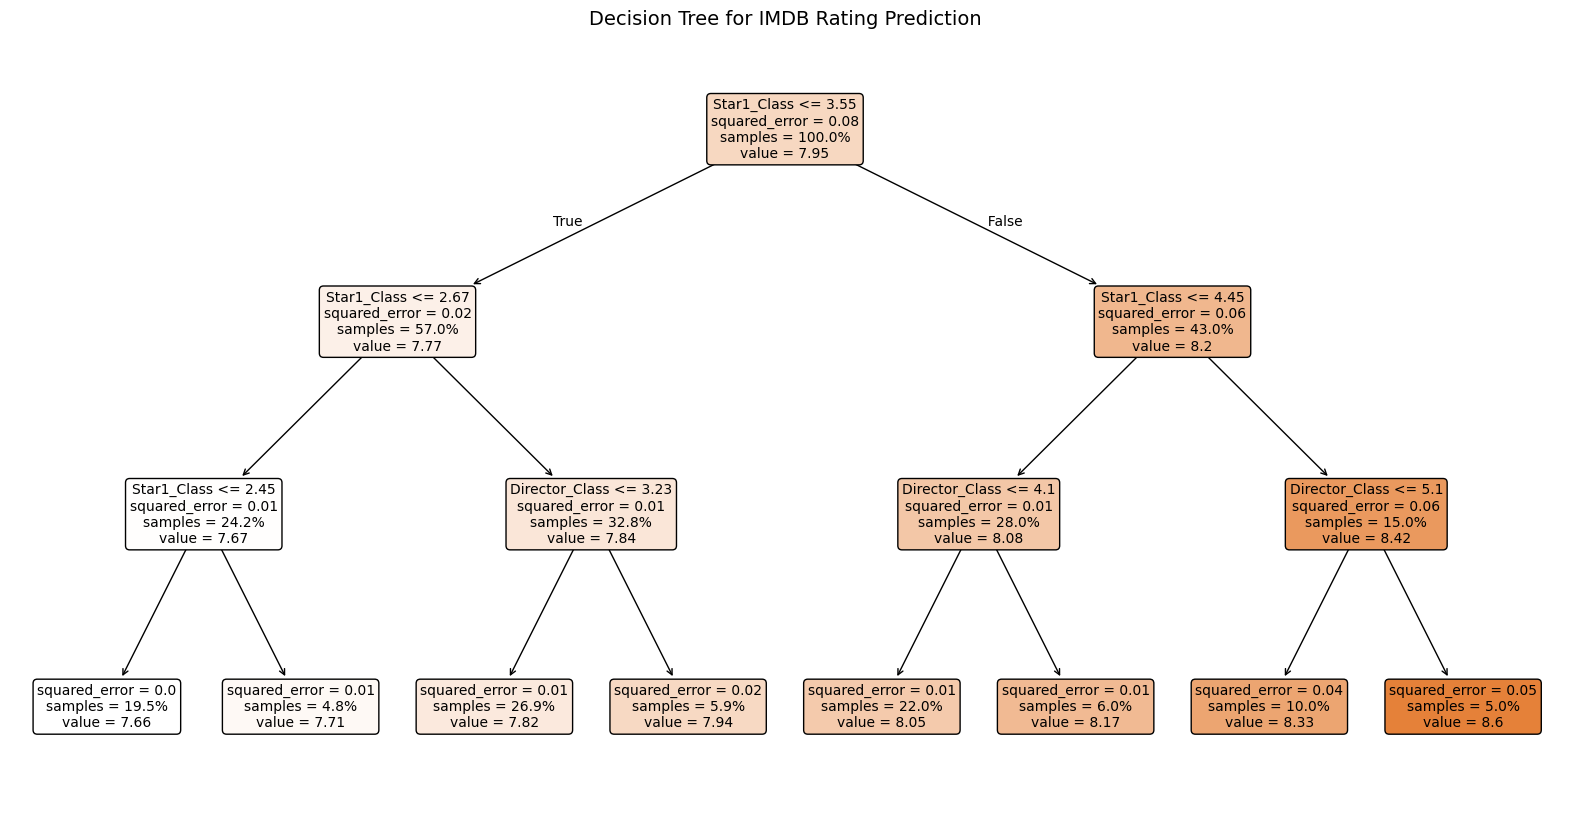

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(
    tree,
    feature_names=X.columns,  
    filled=True,            
    rounded=True,            
    proportion=True,         
    precision=2,             
    fontsize=10             
)
plt.title("Decision Tree for IMDB Rating Prediction", fontsize=14)
plt.show()

Epoch 20/200 | Train Loss: 0.8665 | Val Loss: 0.9172
Epoch 40/200 | Train Loss: 0.7620 | Val Loss: 0.8204
Epoch 60/200 | Train Loss: 0.6718 | Val Loss: 0.7293
Epoch 80/200 | Train Loss: 0.5918 | Val Loss: 0.6411
Epoch 100/200 | Train Loss: 0.5083 | Val Loss: 0.5557
Epoch 120/200 | Train Loss: 0.4326 | Val Loss: 0.4760
Epoch 140/200 | Train Loss: 0.3682 | Val Loss: 0.3999
Epoch 160/200 | Train Loss: 0.3167 | Val Loss: 0.3356
Epoch 180/200 | Train Loss: 0.2561 | Val Loss: 0.2864
Epoch 200/200 | Train Loss: 0.2223 | Val Loss: 0.2548


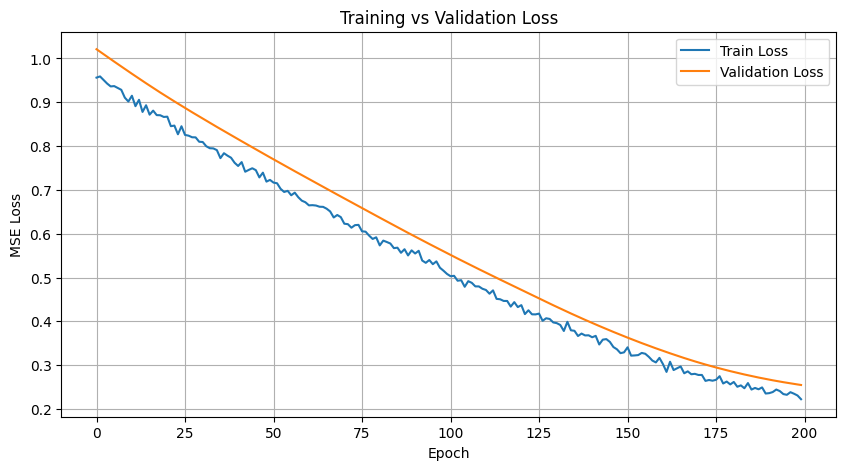


Test Set Metrics:
MSE: 0.0145
R² Score: 0.7742

Sample Predictions:
True: 7.9 | Pred: 7.8
True: 7.7 | Pred: 7.9
True: 7.7 | Pred: 7.7
True: 7.8 | Pred: 7.8
True: 8.0 | Pred: 8.1


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

X = merged_data.drop('IMDB_Rating', axis=1)
y = merged_data['IMDB_Rating']


X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled = y_scaler.transform(y_val.values.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1))

X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train_scaled)
X_val_tensor = torch.FloatTensor(X_val_scaled)
y_val_tensor = torch.FloatTensor(y_val_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test_scaled)

class IMDBRatingPredictor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.network(x)

model = IMDBRatingPredictor(X_train.shape[1])

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5)
epochs = 200
train_losses, val_losses = [], []

best_val_loss = float('inf')
patience = 10
trigger_times = 0

for epoch in range(epochs):

    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) 
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        scheduler.step(val_loss)
    
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        trigger_times = 0
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f'Early stopping at epoch {epoch}')
            break
    
    if (epoch+1) % 20 == 0:
        print(f'Epoch {epoch+1}/{epochs} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}')

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid()
plt.show()

model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test_tensor).numpy()
    y_pred = y_scaler.inverse_transform(y_pred_scaled)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print('\nTest Set Metrics:')
    print(f'MSE: {mse:.4f}')
    print(f'R² Score: {r2:.4f}')
    
    print('\nSample Predictions:')
    for true, pred in zip(y_test[:5], y_pred[:5]):
        print(f'True: {true:.1f} | Pred: {pred[0]:.1f}')